<a href="https://colab.research.google.com/github/WiseSeaSnake/CZN_AD/blob/main/Case40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

# ---------- 1. Путь к файлу ----------
FILE_PATH = "кейс 40.xlsx"

# ---------- 2. Читаем ВСЕ листы сразу ----------
# sheet_name=None → возвращает словарь {имя_листа: DataFrame}
sheets = pd.read_excel(FILE_PATH, sheet_name=None, engine="openpyxl")

print("Листы в файле:", list(sheets.keys()))
print("=" * 60)

# ---------- 3. Формируем отдельные датасеты ----------
product = sheets["Product"].copy()
region  = sheets["Region"].copy()
sales   = sheets["Sales"].copy()
state   = sheets["State"].copy()

# ---------- 4. Приводим типы ----------
# Даты в Sales
sales["OrderDate"] = pd.to_datetime(sales["OrderDate"])
sales["ShipDate"]  = pd.to_datetime(sales["ShipDate"])

# Числовые поля
for col in ["Quantity", "UnitPrice", "DiscountAmount"]:
    sales[col] = pd.to_numeric(sales[col], errors="coerce")

product["RetailPrice"] = pd.to_numeric(product["RetailPrice"], errors="coerce")
product["Channels"]    = pd.to_numeric(product["Channels"], errors="coerce")

# Пустые PromotionCode → NaN
sales["PromotionCode"] = sales["PromotionCode"].replace("", pd.NA)

# ---------- 5. Проверяем каждый датасет ----------
def describe(df, name):
    print(f"\n=== {name} ===")
    print(f"Размер: {df.shape}")
    print(f"Колонки: {list(df.columns)}")
    print(f"Пропуски:\n{df.isna().sum()[df.isna().sum() > 0]}")
    print(df.head(3))

describe(product, "Product")
describe(region,  "Region")
describe(sales,   "Sales")
describe(state,   "State")

# ---------- 6. (Опционально) Сохраняем каждый лист в отдельный CSV ----------
for name, df in sheets.items():
    df.to_csv(f"{name}.csv", index=False, encoding="utf-8-sig")
print("\nCSV-файлы сохранены.")

Листы в файле: ['Product', 'Region', 'Sales', 'State']

=== Product ===
Размер: (20, 9)
Колонки: ['ProductID', 'ProductSKU', 'ProductName', 'ProductCategory', 'ItemGroup', 'KitType', 'Channels', 'Demographic', 'RetailPrice']
Пропуски:
Series([], dtype: int64)
   ProductID     ProductSKU                ProductName ProductCategory  \
0          1  1010-GL120-3C  Trainer - Tailspin GL-120          Glider   
1          2  1010-GL155-4C  Trainer - Tailspin GL-155          Glider   
2          3   2030-PCUB-3C        Piper Cub 3 Channel         Trainer   

  ItemGroup KitType  Channels   Demographic  RetailPrice  
0  Airplane     RTF         3        Novice        79.15  
1  Airplane     RTF         4  Intermediate       216.65  
2  Airplane     RTF         3      Beginner        84.65  

=== Region ===
Размер: (6, 2)
Колонки: ['RegionID', 'RegionName']
Пропуски:
Series([], dtype: int64)
   RegionID   RegionName
0         1      Midwest
1         2  New England
2         3    Northeast

=== 

In [9]:
import numpy as np

df = (
    sales
    .merge(product, on="ProductID", how="left")
    .merge(state.rename(columns={"StateID": "CustomerStateID"}),
           on="CustomerStateID", how="left")
    .merge(region, on="RegionID", how="left")
)

order = [
    # ключи и даты
    "OrderNumber", "OrderDate", "ShipDate",
    # география
    "CustomerStateID", "StateCode", "StateName", "RegionID", "RegionName",
    # товар
    "ProductID", "ProductSKU", "ProductName", "ProductCategory",
    "ItemGroup", "KitType", "Channels", "Demographic",
    # деньги и количество
    "Quantity", "UnitPrice", "RetailPrice", "DiscountAmount", "PromotionCode",
]
df = df[order]

"""
df["OrderWeekday"]= df["OrderDate"].dt.dayofweek

# Денежные
df["GrossAmount"]   = df["Quantity"] * df["UnitPrice"]
df["NetAmount"]     = df["GrossAmount"] - df["DiscountAmount"]
df["DiscountRate"]  = df["DiscountAmount"] / df["GrossAmount"].replace(0, np.nan)
df["PriceDiff"]     = df["RetailPrice"] - df["UnitPrice"]
df["PriceDiffPct"]  = df["PriceDiff"] / df["RetailPrice"].replace(0, np.nan)

# Бинарные
df["HasPromo"]      = df["PromotionCode"].notna().astype(int)
df["IsHelicopter"]  = (df["ItemGroup"] == "Helicopter").astype(int)
df["IsKIT"]         = (df["KitType"] == "KIT").astype(int)
"""


print(df.shape)         # (39, 33)
print(df.head())

(377741, 21)
  OrderNumber  OrderDate   ShipDate  CustomerStateID StateCode   StateName  \
0  TT00017434 2017-01-01 2017-01-09               14        IN     Indiana   
1  TT00017445 2017-01-02 2017-01-04               13        IL    Illinois   
2  TT00017456 2017-01-06 2017-01-09               35        OH        Ohio   
3  TT00017467 2017-01-08 2017-01-11                3        AZ     Arizona   
4  TT00017478 2017-01-08 2017-01-10                5        CA  California   

   RegionID RegionName  ProductID    ProductSKU  ... ProductCategory  \
0         1    Midwest          3  2030-PCUB-3C  ...         Trainer   
1         1    Midwest          3  2030-PCUB-3C  ...         Trainer   
2         1    Midwest          3  2030-PCUB-3C  ...         Trainer   
3         5   Southern          3  2030-PCUB-3C  ...         Trainer   
4         6  Southwest          3  2030-PCUB-3C  ...         Trainer   

  ItemGroup KitType Channels  Demographic Quantity  UnitPrice  RetailPrice  \
0  Airp

In [10]:
assert len(df) == len(sales), "Потеря строк при merge!"
assert df["StateName"].notna().all(), "Не все штаты сматчились"
assert df["RegionName"].notna().all(), "Не все регионы сматчились"
assert df["ProductName"].notna().all(), "Не все товары сматчились"

print("Все проверки пройдены ✔")

Все проверки пройдены ✔


EDA по консолидированному датафрейму

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [12]:
print("=" * 60)
print("РАЗМЕР:", df.shape)
print("=" * 60)

print("\nТипы данных:")
print(df.dtypes)

print("\nПервые 5 строк:")
display(df.head())

print("\nСтатистика по числовым:")
display(df.describe(include=[np.number]).T)

print("\nСтатистика по категориальным:")
display(df.describe(include=["object"]).T)

РАЗМЕР: (377741, 21)

Типы данных:
OrderNumber                object
OrderDate          datetime64[ns]
ShipDate           datetime64[ns]
CustomerStateID             int64
StateCode                  object
StateName                  object
RegionID                    int64
RegionName                 object
ProductID                   int64
ProductSKU                 object
ProductName                object
ProductCategory            object
ItemGroup                  object
KitType                    object
Channels                    int64
Demographic                object
Quantity                    int64
UnitPrice                 float64
RetailPrice               float64
DiscountAmount            float64
PromotionCode              object
dtype: object

Первые 5 строк:


,OrderNumber,OrderDate,ShipDate,CustomerStateID,StateCode,StateName,RegionID,RegionName,ProductID,ProductSKU,ProductName,ProductCategory,ItemGroup,KitType,Channels,Demographic,Quantity,UnitPrice,RetailPrice,DiscountAmount,PromotionCode
0,TT00017434,2017-01-01,2017-01-09,14,IN,Indiana,1,Midwest,3,2030-PCUB-3C,Piper Cub 3 Channel,Trainer,Airplane,RTF,3,Beginner,1,69.95,84.65,0.0,NaN
1,TT00017445,2017-01-02,2017-01-04,13,IL,Illinois,1,Midwest,3,2030-PCUB-3C,Piper Cub 3 Channel,Trainer,Airplane,RTF,3,Beginner,1,69.95,84.65,0.0,NaN
2,TT00017456,2017-01-06,2017-01-09,35,OH,Ohio,1,Midwest,3,2030-PCUB-3C,Piper Cub 3 Channel,Trainer,Airplane,RTF,3,Beginner,1,69.95,84.65,0.0,NaN
3,TT00017467,2017-01-08,2017-01-11,3,AZ,Arizona,5,Southern,3,2030-PCUB-3C,Piper Cub 3 Channel,Trainer,Airplane,RTF,3,Beginner,1,69.95,84.65,0.0,NaN
4,TT00017478,2017-01-08,2017-01-10,5,CA,California,6,Southwest,3,2030-PCUB-3C,Piper Cub 3 Channel,Trainer,Airplane,RTF,3,Beginner,1,69.95,84.65,0.0,NaN



Статистика по числовым:


,count,mean,std,min,25%,50%,75%,max
CustomerStateID,377741.0,21.499850,14.384212,1.00,9.00,20.00,33.00,50.00
RegionID,377741.0,3.528555,1.819899,1.00,1.00,4.00,5.00,6.00
ProductID,377741.0,11.361158,5.497228,1.00,6.00,13.00,14.00,20.00
Channels,377741.0,4.793316,1.100682,3.00,4.00,5.00,6.00,6.00
Quantity,377741.0,1.242505,0.519523,1.00,1.00,1.00,1.00,3.00
UnitPrice,377741.0,272.203814,164.663863,49.95,168.95,199.95,458.95,579.55
RetailPrice,377741.0,299.452877,180.125547,63.55,188.05,239.95,579.55,579.55
DiscountAmount,377741.0,3.404085,12.125159,0.00,0.00,0.00,0.00,434.65



Статистика по категориальным:


,count,unique,top,freq
OrderNumber,377741,377741,TT03794834,1
StateCode,377741,50,CA,43884
StateName,377741,50,California,43884
RegionName,377741,6,Southern,118175
ProductSKU,377741,20,3050-THeli-MaxPro-6C,99197
ProductName,377741,20,Tailspin Heli - Max Pro Flight - 6ch,99197
ProductCategory,377741,6,Collective pitch,147083
ItemGroup,377741,2,Helicopter,193016
KitType,377741,2,RTF,211500
Demographic,377741,5,Professional,147083


Пропуски и дубликаты

Пропуски:
PromotionCode    316033
ShipDate           3423
dtype: int64


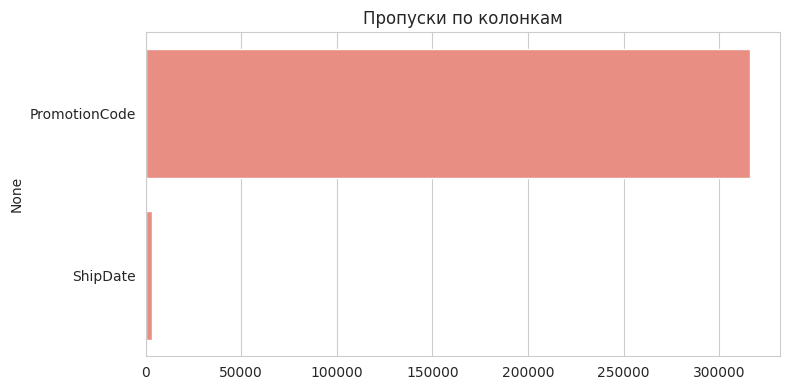


Полных дубликатов: 0
Дубликатов по OrderNumber: 0


In [13]:
# Пропуски
miss = df.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]
print("Пропуски:")
print(miss)

if len(miss):
    plt.figure(figsize=(8, 4))
    sns.barplot(x=miss.values, y=miss.index, color="salmon")
    plt.title("Пропуски по колонкам")
    plt.tight_layout()
    plt.show()

# Дубликаты
print("\nПолных дубликатов:", df.duplicated().sum())
print("Дубликатов по OrderNumber:", df["OrderNumber"].duplicated().sum())

Ожидаемый вывод: пропуски только в PromotionCode (большинство заказов без акции).

3. Анализ категориальных признаков



--- ProductCategory ---
ProductCategory
Collective pitch    147083
Trainer             115627
Warbird              53608
Co-Axial             43086
Glider               15490
Fixed pitch           2847
Name: count, dtype: int64

--- ItemGroup ---
ItemGroup
Helicopter    193016
Airplane      184725
Name: count, dtype: int64

--- KitType ---
KitType
RTF    211500
KIT    166241
Name: count, dtype: int64

--- Demographic ---
Demographic
Professional    147083
Intermediate    127671
Advanced         56267
Novice           30513
Beginner         16207
Name: count, dtype: int64

--- RegionName ---
RegionName
Southern             118175
Midwest               96603
Northeast             48050
Southwest             47824
Pacific Northwest     40065
New England           27024
Name: count, dtype: int64

--- StateName ---
StateName
California        43884
Florida           21862
New York          16472
Illinois          14803
Texas             14234
Georgia           11978
Arizona           11462

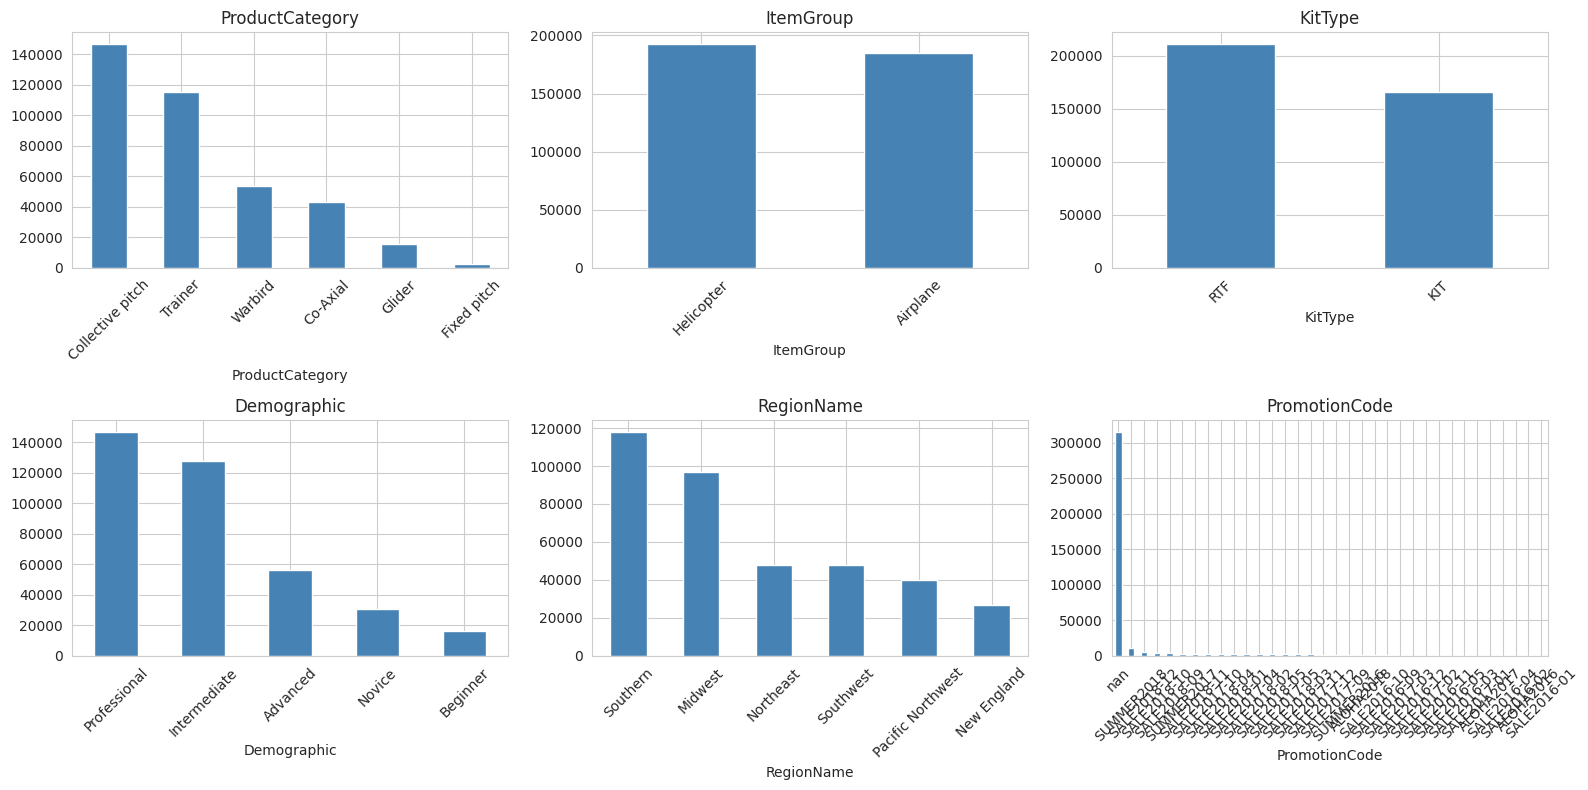

In [14]:
cat_cols = [
    "ProductCategory", "ItemGroup", "KitType", "Demographic",
    "RegionName", "StateName", "PromotionCode",
]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, ["ProductCategory", "ItemGroup", "KitType",
                                "Demographic", "RegionName", "PromotionCode"]):
    df[col].value_counts(dropna=False).plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Ключевые наблюдения:

В Sales только 2 товара: ProductID = 3 и ProductID = 13.

ItemGroup: смесь Airplane / Helicopter.

PromotionCode: почти всё NaN → HasPromo ≈ 0.08

Анализ числовых признаков

KeyError: 'ShipDays'

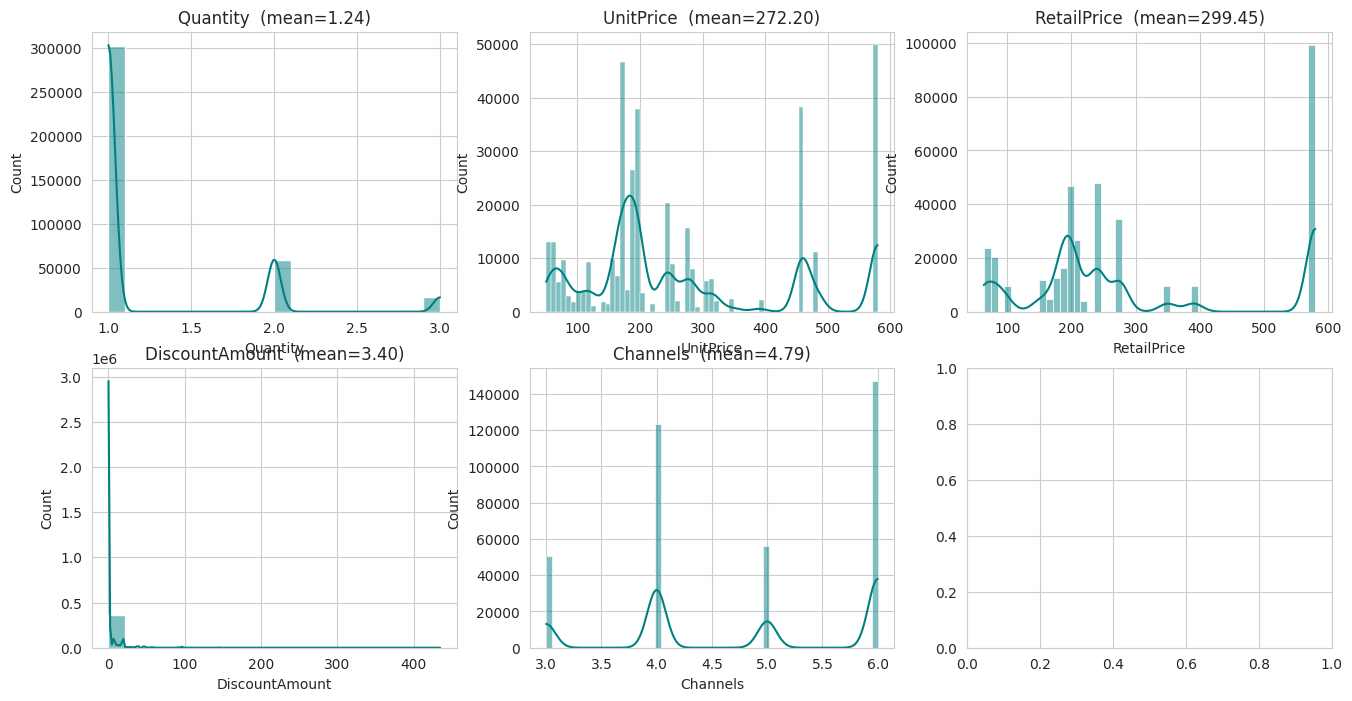

In [15]:
num_cols = ["Quantity", "UnitPrice", "RetailPrice",
            "DiscountAmount", "Channels", "ShipDays"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="teal")
    ax.set_title(f"{col}  (mean={df[col].mean():.2f})")
plt.tight_layout()
plt.show()